<a href="https://colab.research.google.com/github/NandanaRN/Natural_Language_Processing/blob/main/PROJECT_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NLP Project 8: Product Feedback Analysis

# Problem Statement
A retail company has recently launched new products and receives customer feedback through surveys, online forms, and e-commerce platforms. Customers share opinions regarding product quality, pricing, packaging, and usability. The management wants to analyze this feedback efficiently to
understand customer expectations and improve product performance. NLP techniques can help automate feedback analysis and provide meaningful insights for business decisions.

Tasks


1.   Collect product feedback data
2.   Preprocess feedback text


1.   Analyze customer sentiments.
2.    Identify product improvement areas.


1.   Generate business insights.








Step 1: Import Libraries

In [22]:
import pandas as pd
import nltk
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from textblob import TextBlob

from wordcloud import WordCloud

import string

Step 2: Download NLTK Resources

In [23]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

Step 3: Create Product Feedback Dataset

In [24]:
feedback = {
    "Feedback":[
        "Excellent product with amazing quality",
        "Packaging was damaged",
        "Very satisfied with the purchase",
        "Price is too high",
        "Battery backup is excellent",
        "Delivery was very late",
        "Customer service is helpful",
        "Poor build quality",
        "Worth every penny",
        "The product stopped working after one week",
        "Easy to use and lightweight",
        "Not satisfied with the performance",
        "Looks premium and stylish",
        "Bad packaging but good product",
        "Highly recommended"
    ]
}

df = pd.DataFrame(feedback)

df.head()

,Feedback
0,Excellent product with amazing quality
1,Packaging was damaged
2,Very satisfied with the purchase
3,Price is too high
4,Battery backup is excellent


Step 4: Preprocess Text

In [25]:
nltk.download('punkt_tab')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):

    text = text.lower()

    text = text.translate(str.maketrans('', '', string.punctuation))

    words = word_tokenize(text)

    words = [word for word in words if word not in stop_words]

    words = [lemmatizer.lemmatize(word) for word in words]

    return " ".join(words)

df["Processed_Feedback"] = df["Feedback"].apply(preprocess)

df.head()

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,Feedback,Processed_Feedback
0,Excellent product with amazing quality,excellent product amazing quality
1,Packaging was damaged,packaging damaged
2,Very satisfied with the purchase,satisfied purchase
3,Price is too high,price high
4,Battery backup is excellent,battery backup excellent


Step 5: Sentiment Analysis

In [26]:
def get_sentiment(text):

    score = TextBlob(text).sentiment.polarity

    if score > 0:
        return "Positive"

    elif score < 0:
        return "Negative"

    else:
        return "Neutral"

df["Sentiment"] = df["Processed_Feedback"].apply(get_sentiment)

df

,Feedback,Processed_Feedback,Sentiment
0,Excellent product with amazing quality,excellent product amazing quality,Positive
1,Packaging was damaged,packaging damaged,Neutral
2,Very satisfied with the purchase,satisfied purchase,Positive
3,Price is too high,price high,Positive
4,Battery backup is excellent,battery backup excellent,Positive
5,Delivery was very late,delivery late,Negative
6,Customer service is helpful,customer service helpful,Neutral
7,Poor build quality,poor build quality,Negative
8,Worth every penny,worth every penny,Positive
9,The product stopped working after one week,product stopped working one week,Neutral


Step 6: Count Sentiments

In [27]:
sentiment_count = df["Sentiment"].value_counts()

print(sentiment_count)

Sentiment
Positive    10
Neutral      3
Negative     2
Name: count, dtype: int64


Step 7: Plot Sentiment Distribution

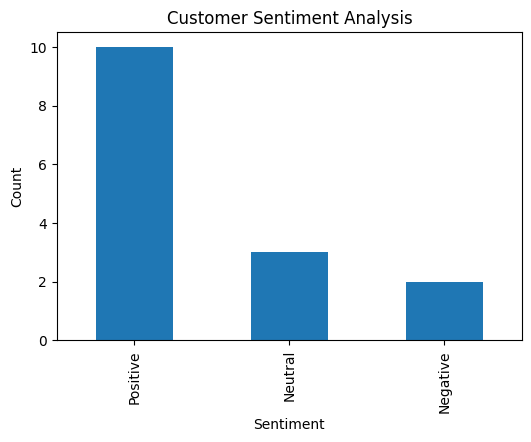

In [28]:
plt.figure(figsize=(6,4))

sentiment_count.plot(kind='bar')

plt.title("Customer Sentiment Analysis")

plt.xlabel("Sentiment")

plt.ylabel("Count")

plt.show()

Step 8: Generate Word Cloud

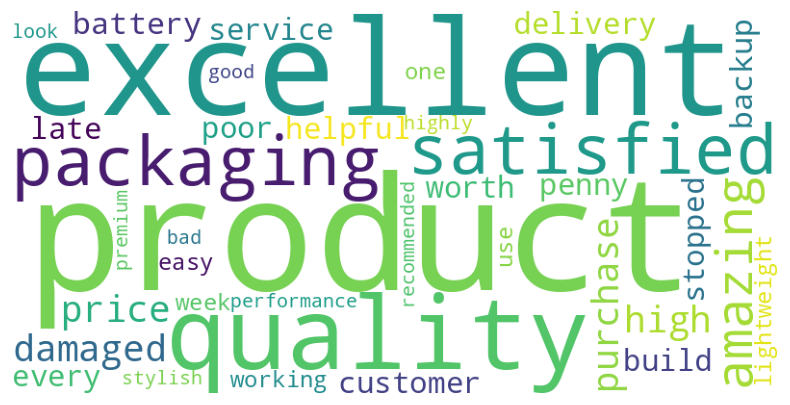

In [29]:
text = " ".join(df["Processed_Feedback"])

wordcloud = WordCloud(width=800,
                      height=400,
                      background_color='white').generate(text)

plt.figure(figsize=(10,5))

plt.imshow(wordcloud)

plt.axis("off")

plt.show()

Step 9: Product Improvement Areas

In [30]:
negative_feedback = df[df["Sentiment"]=="Negative"]

negative_feedback

,Feedback,Processed_Feedback,Sentiment
5,Delivery was very late,delivery late,Negative
7,Poor build quality,poor build quality,Negative


Step 10: Business Insights

In [31]:
positive = len(df[df["Sentiment"]=="Positive"])
negative = len(df[df["Sentiment"]=="Negative"])
neutral = len(df[df["Sentiment"]=="Neutral"])

print("Positive Reviews :", positive)
print("Negative Reviews :", negative)
print("Neutral Reviews :", neutral)

Positive Reviews : 10
Negative Reviews : 2
Neutral Reviews : 3
